Importing modules

In [14]:
import os

from dotenv import load_dotenv
from openai import OpenAI
import json
import re 

import matplotlib.pyplot as plt 

Laoding the the model. In this example, I am using my local Ollama model. 

In [15]:
load_dotenv()

client = OpenAI(
    base_url=os.environ["API_URL"],
    api_key=os.environ["API_KEY"],
)

Summerizing the content and saving it to the .json file 

In [16]:
%pwd

'c:\\Users\\STUDENT\\Documents\\LLM Basics\\LLM-Basics\\01_Intro-to-LLMs'

In [17]:
# Loop through the articles, summerize them, and save the summaries to a JSON file with their name and summary.

path_to_articles = "../data/01_Intro-to-LLMs"
output_file = "summaries.json"

summaries = []


for filename in sorted(os.listdir(path_to_articles)):
    if not filename.endswith(".txt"):
        continue
    
    file_path = os.path.join(path_to_articles, filename)
    
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
    
    response = client.chat.completions.create(
        model=os.environ["API_MODEL"],
        messages=[
            {
                "role": "user",
                "content": f"You are a research scientist who cares about modern technology. Summarize the following article in 3-5 sentences, stating the main points, the author's opinion, and the potential impact/applicaiton in today's world. Just return the summary, no other text:\n\n{content}",
            }
        ],
    )

    summary = response.choices[0].message.content
    summaries.append({
        "article": filename,
        "summary": summary,
    })

    print(f"\n--- {filename} ---")
    print(summary)
    
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(summaries, f, indent=2, ensure_ascii=False)
print(f"\nSaved {len(summaries)} summaries to {output_file}")



--- article_01.txt ---
Artificial intelligence has made significant advancements in recent years, with applications ranging from virtual assistants and autonomous vehicles to strategy games like chess and Go. The author expresses an optimistic view on AI's future potential, citing breakthroughs in generative AI and deep learning. However, concerns over AI safety, unintended consequences, and existential risks have prompted discussions of regulation. With the emergence of large language models and reasoning models, researchers are gaining traction on complex problems in reasoning and decision-making.

--- article_02.txt ---
Here is a summary of the article:

Quantum computing relies on quantum phenomena like superposition and entanglement, which enable faster calculations compared to classical computers. However, current hardware implementations are experimental and only suitable for specialized tasks. Researchers claim that certain devices can outperform classical computers, but these

Generate 20 two-dimensional random numbers using an LLM and ask the LLM to find the shortest path across these 20 points. Plot the points and the path using matplotlib.

In [32]:
response_01 = client.chat.completions.create(
    model=os.environ["API_MODEL"],
    messages=[
    {
        "role": "system",
        "content": "You return only valid JSON. Never write code or explanations."
    },
    {
        "role": "user",
        "content": """Generate exactly 20 random 2D points.

Rules:
- Each point is [x, y]
- x and y are integers from 0 to 100
- All 20 points must be different
- Return ONLY a JSON array, nothing else

Example format:
[[12, 45], [3, 88], [67, 21], ...] """
    }
]
)

content = f"""You are given 20 points:
{response_01.choices[0].message.content.strip()}

Find the shortest route that visits EVERY point exactly once and returns to the start (Traveling Salesperson Problem).

Return ONLY a JSON array of the points in visit order.
Do not write Python code.
Do not add explanations.

Example:
[[12, 45], [67, 21], [3, 88], ..., [7, 25]]"""


response_02 = client.chat.completions.create(
    model=os.environ["API_MODEL"],
    messages=[{"role": "user", "content": content
              }],
)

points = response_01.choices[0].message.content.strip()


In [33]:
print(points)
print("The shortest path is: ", response_02.choices[0].message.content)

{"points": [[95, 22], [11, 79], [46, 13], [98, 94], [33, 41], [85, 18], [57, 68], [25, 97], [67, 88], [31, 42], [19, 29], [83, 76], [52, 59], [46, 47], [13, 94], [44, 91], [77, 99], [29, 12], [85, 22]]}
The shortest path is:  [[11, 79], [13, 94], [85, 22], [19, 29], [52, 59], [33, 41], [46, 47], [44, 91],
[23, 84], [77, 99], [46, 68], [25, 97], [67, 88], [57, 68], [85, 18], [46, 13],
[29, 12], [98, 94], [83, 76], [31, 42]]


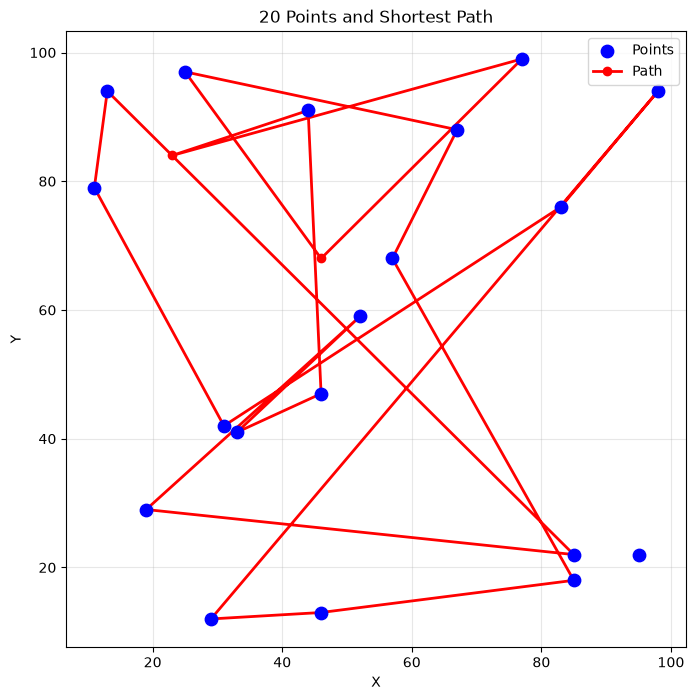

In [34]:
points = json.loads(response_01.choices[0].message.content)["points"]
path = json.loads(response_02.choices[0].message.content)

xs = [p[0] for p in points]
ys = [p[1] for p in points]

path_xs = [p[0] for p in path] + [path[0][0]]
path_ys = [p[1] for p in path] + [path[0][1]]

plt.figure(figsize=(8, 8))
plt.scatter(xs, ys, color="blue", s=80, zorder=3, label="Points")
plt.plot(path_xs, path_ys, color="red", linewidth=2, marker="o", label="Path")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("20 Points and Shortest Path")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
